In [ ]:
import pandas as pd
import glob

#csv = pd.read_csv("../msi_benchmark.csv")

paths = glob.glob("../baseline_results/*.csv")
paths = [path for path in paths if 'results' not in path.split('/')[-1]]

csv = pd.concat([pd.read_csv(path) for path in paths])

# Rename mouse_index to dataset
#csv = csv.rename(columns={'mouse_index': 'dataset'})
# Reorder columns to put method, dataset and seed first
#csv = csv[['method', 'dataset', 'seed'] + [col for col in csv.columns if col not in ['method', 'dataset', 'seed']]]



Drop the ami_avg column
csv = csv.drop('ami_avg', axis=1)


csv = pd.read_csv('../msi_benchmark.csv')
csv["dataset"] = "msi"



csv = csv[csv.method.isin(['tsne', 'trimap', 'pacmac', 'PCC5', 'PCC', 'PCC2', 'PCC4', 'localmap', 'umap',
       'phate', 'PCUMAP',
       'dtne', 'pca'])]


csv = csv[csv.method.isin(['tsne', 'trimap', 'pacmac', 'PCC5', 'localmap', 'umap',
       'phate', 'PCUMAP', 
       'dtne', 'pca'])]

csv.loc[csv.method == 'PCC5', 'method'] = 'MiCS+LMC (ours)'
csv.loc[csv.method == 'PCUMAP', 'method'] = 'UMAP+LMC (ours)'


csv.loc[csv.method == 'PCC2_No_Cluster', 'method'] = 'LMC'
csv.loc[csv.method == 'PCC2_No_Corr', 'method'] = 'MiCS'


csv = csv[~csv.dataset.isin(["swiss_roll", "mammoth", "cifar", "cifar100", "mnist", "fashion_mnist"])]


# Drop the ami_avg column
#csv = csv.drop('ami_avg', axis=1)
# Rename columns

# Drop the within_cluster_pr_avg column
csv = csv.drop('within_cluster_pr_avg', axis=1)


csv = csv.rename(columns={
    'within_cluster_pr_avg': 'Intra-cluster Mantel correlation',
    'between_centers_pr_avg': 'Centroid-level Mantel correlation',
    'mrre_false': 'MRRE Intrusions',
    'mrre_missing': 'MRRE Exclusions',
    'pearson_r': 'Mantel Distance Pearson Correlation',
    'spearman_rho': 'Mantel Distance Spearman Correlation',

})

# Rename methods to proper capitalization/formatting
method_renames = {
    'pca': 'PCA',
    'tsne': 't-SNE', 
    'umap': 'UMAP',
    'trimap': 'Trimap',
    'pacmac': 'PaCMAP',
    'dtne': 'DTNE',
    'phate': 'Phate',
    'localmap': 'LocalMAP'
}

csv['method'] = csv['method'].replace(method_renames)





In [11]:
# Compute means and stds over both seeds and datasets
metrics = csv.columns[3:]
methods = csv['method'].unique()
seeds = csv['seed'].unique()

# Initialize lists to store statistics
method_stats = []

for method in methods:
    method_data = csv[csv['method'] == method]
    
    # For each metric, compute:
    # 1. Mean over all data
    # 2. Std over seeds (averaging datasets first)
    # 3. Std over datasets (averaging seeds first)
    stats_row = {'method': method}
    
    for metric in metrics:
        # Overall mean across everything
        overall_mean = method_data[metric].mean()
        
        # Std over seeds
        # First average over datasets for each seed
        seed_means = method_data.groupby('seed')[metric].mean()
        seed_std = seed_means.std()
        
        # Std over datasets
        # First average over seeds for each dataset
        dataset_means = method_data.groupby('dataset')[metric].mean()
        dataset_std = dataset_means.std()
        
        stats_row[f'{metric}_mean'] = overall_mean
        stats_row[f'{metric}_seed_std'] = seed_std
        stats_row[f'{metric}_dataset_std'] = dataset_std
        
    method_stats.append(stats_row)

# Create DataFrame with method statistics
stats_df = pd.DataFrame(method_stats)

# Set method as index for easier access
stats_df = stats_df.set_index('method')

# Calculate overall mean of mean metrics for sorting
mean_cols = [col for col in stats_df.columns if col.endswith('_mean')]
stats_df['overall_mean'] = stats_df[mean_cols].mean(axis=1)

# Sort by overall mean and drop the temporary column
stats_df = stats_df.sort_values('overall_mean', ascending=False).drop('overall_mean', axis=1)

# Display first few rows
print("Created stats_df DataFrame with shape:", stats_df.shape)
stats_df


Created stats_df DataFrame with shape: (7, 33)


,trustworthiness_mean,trustworthiness_seed_std,trustworthiness_dataset_std,continuity_mean,continuity_seed_std,continuity_dataset_std,MRRE Intrusions_mean,MRRE Intrusions_seed_std,MRRE Intrusions_dataset_std,MRRE Exclusions_mean,...,ca_continuity_dataset_std,Centroid-level Mantel correlation_mean,Centroid-level Mantel correlation_seed_std,Centroid-level Mantel correlation_dataset_std,knn_label_metrics_mean,knn_label_metrics_seed_std,knn_label_metrics_dataset_std,linear_probe_cv_mean,linear_probe_cv_seed_std,linear_probe_cv_dataset_std
method,,,,,,,,,,,,,,,,,,,,,
PCC,0.973921,0.000412,0.002040,0.974339,0.000645,0.006624,0.972915,0.000567,0.001770,0.975280,...,0.001430,0.984462,0.003243,0.007361,0.428795,0.038322,0.094524,0.412102,0.039660,0.080979
PCA,0.971513,0.000506,0.007136,0.986042,0.000198,0.002815,0.969501,0.000656,0.007449,0.986037,...,0.001151,0.984906,0.000881,0.004572,0.401645,0.042440,0.087144,0.405221,0.030512,0.081906
UMAP,0.984643,0.001006,0.001750,0.980341,0.000639,0.004039,0.985407,0.000948,0.001415,0.983044,...,0.000305,0.895251,0.017179,0.024983,0.535887,0.043574,0.089044,0.493203,0.046228,0.085898
pacmap,0.984328,0.000540,0.001052,0.980477,0.000052,0.003723,0.984595,0.000529,0.000723,0.983264,...,0.001038,0.817091,0.021723,0.048496,0.526841,0.045633,0.087342,0.478374,0.036680,0.073710
Trimap,0.966283,0.003401,0.012254,0.964738,0.006848,0.011726,0.968442,0.003106,0.012822,0.968608,...,0.005637,0.783403,0.035111,0.140642,0.500804,0.036177,0.090631,0.457428,0.029190,0.078223
Phate,0.963229,0.002891,0.003388,0.970247,0.002742,0.004890,0.967874,0.002070,0.003710,0.974993,...,0.001082,0.787266,0.072688,0.044811,0.496959,0.047985,0.087498,0.453225,0.045501,0.082275
TSNE,0.981854,0.001751,0.002604,0.975485,0.000157,0.003810,0.986666,0.000885,0.001472,0.979806,...,0.000747,0.669359,0.026283,0.085945,0.549762,0.036038,0.081324,0.497992,0.018231,0.068541


,trustworthiness,continuity,MRRE Intrusions,MRRE Exclusions,Mantel Distance Pearson Correlation,Mantel Distance Spearman Correlation,ca_trustworthiness,ca_continuity,Centroid-level Mantel correlation,knn_label_metrics,linear_probe_cv,seed,dataset,method
5,0.969856,0.965392,0.975632,0.973824,0.472744,0.573149,0.975564,0.992996,0.563142,0.564103,0.502756,0,0,Trimap
6,0.962763,0.964963,0.968249,0.971878,0.529336,0.642838,0.967267,0.992575,0.721380,0.529075,0.502742,0,0,Phate
12,0.958659,0.959578,0.959734,0.961865,0.827110,0.840337,0.965242,0.985286,0.889461,0.509551,0.468232,0,1,Trimap
13,0.960812,0.971617,0.966773,0.976319,0.705241,0.758233,0.966366,0.991658,0.779231,0.539316,0.490891,0,1,Phate
19,0.982432,0.983272,0.983090,0.984649,0.815434,0.874426,0.985420,0.996947,0.871055,0.502814,0.474180,0,2,Trimap
20,0.963847,0.969846,0.969534,0.975265,0.749302,0.774161,0.967555,0.993039,0.798081,0.476167,0.408137,0,2,Phate
26,0.960597,0.963621,0.961167,0.964961,0.806505,0.819050,0.963777,0.993311,0.876161,0.358533,0.329501,0,3,Trimap
27,0.960043,0.969393,0.963037,0.972954,0.699916,0.790252,0.963356,0.995148,0.713312,0.352798,0.325335,0,3,Phate
33,0.974827,0.965248,0.978652,0.973690,0.535220,0.639877,0.980302,0.991124,0.627036,0.587225,0.510999,1,0,Trimap
34,0.958125,0.964265,0.963700,0.970563,0.733625,0.784933,0.963342,0.993121,0.865302,0.537088,0.500024,1,0,Phate


In [9]:
csv

,method,dataset,seed,trustworthiness,continuity,MRRE Intrusions,MRRE Exclusions,Mantel Distance Pearson Correlation,Mantel Distance Spearman Correlation,ca_trustworthiness,ca_continuity,Centroid-level Mantel correlation,knn_label_metrics,linear_probe_cv
5,Trimap,0,0,0.969856,0.965392,0.975632,0.973824,0.472744,0.573149,0.975564,0.992996,0.563142,0.564103,0.502756
6,Phate,0,0,0.962763,0.964963,0.968249,0.971878,0.529336,0.642838,0.967267,0.992575,0.721380,0.529075,0.502742
12,Trimap,1,0,0.958659,0.959578,0.959734,0.961865,0.827110,0.840337,0.965242,0.985286,0.889461,0.509551,0.468232
13,Phate,1,0,0.960812,0.971617,0.966773,0.976319,0.705241,0.758233,0.966366,0.991658,0.779231,0.539316,0.490891
19,Trimap,2,0,0.982432,0.983272,0.983090,0.984649,0.815434,0.874426,0.985420,0.996947,0.871055,0.502814,0.474180
20,Phate,2,0,0.963847,0.969846,0.969534,0.975265,0.749302,0.774161,0.967555,0.993039,0.798081,0.476167,0.408137
26,Trimap,3,0,0.960597,0.963621,0.961167,0.964961,0.806505,0.819050,0.963777,0.993311,0.876161,0.358533,0.329501
27,Phate,3,0,0.960043,0.969393,0.963037,0.972954,0.699916,0.790252,0.963356,0.995148,0.713312,0.352798,0.325335
33,Trimap,0,1,0.974827,0.965248,0.978652,0.973690,0.535220,0.639877,0.980302,0.991124,0.627036,0.587225,0.510999
34,Phate,0,1,0.958125,0.964265,0.963700,0.970563,0.733625,0.784933,0.963342,0.993121,0.865302,0.537088,0.500024


In [4]:
# Create a new DataFrame with means and stds combined
formatted_df = pd.DataFrame(index=stats_df.index)

# Define metrics in desired order
metric_order = [
    'Mantel Distance Pearson Correlation',
    'Mantel Distance Spearman Correlation', 
    'Centroid-level Mantel correlation',
    #'Intra-cluster Mantel correlation',
    'continuity',
    'trustworthiness',
    'MRRE Intrusions',
    'MRRE Exclusions',
    # "stress",
    # "knn_label_metrics",
    # "linear_probe_cv",
    # "kl_divergence",

]

# Combine mean and std for each metric in order
for metric in metric_order:
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_dataset_std'
    formatted_df[metric] = stats_df[mean_col].round(7).astype(str) + ' ± ' + stats_df[std_col].round(7).astype(str)

# Capitalize column names
formatted_df.columns = [col.capitalize() for col in formatted_df.columns]


# Display the formatted DataFrame
formatted_df


,Mantel distance pearson correlation,Mantel distance spearman correlation,Centroid-level mantel correlation,Continuity,Trustworthiness,Mrre intrusions,Mrre exclusions
method,,,,,,,
UMAP+LMC (ours),0.9167198 ± 0.0715724,0.9202141 ± 0.0651602,0.9280203 ± 0.0620825,0.9434751 ± 0.0698204,0.9267608 ± 0.0879302,0.8850189 ± 0.0998911,0.9021274 ± 0.0987416
MiCS+LMC (ours),0.9222904 ± 0.0685331,0.9309074 ± 0.0471204,0.9094702 ± 0.0691876,0.9352792 ± 0.0577199,0.9090899 ± 0.09209,0.872607 ± 0.097569,0.9046816 ± 0.0651961
PCA,0.8215029 ± 0.1636823,0.8215995 ± 0.1452258,0.8656283 ± 0.1092673,0.9283352 ± 0.0780977,0.8777277 ± 0.1033427,0.8271077 ± 0.0985913,0.8888705 ± 0.088886
Trimap,0.5910124 ± 0.220382,0.6438633 ± 0.2416113,0.7977176 ± 0.1334334,0.9237397 ± 0.0890999,0.9064674 ± 0.0955283,0.8710415 ± 0.1096707,0.8876971 ± 0.1136468
PaCMAP,0.553377 ± 0.1761681,0.6120591 ± 0.1895803,0.7617391 ± 0.0938389,0.919164 ± 0.0875343,0.9022478 ± 0.0987285,0.870998 ± 0.1053139,0.8862862 ± 0.1022841
LocalMAP,0.5592554 ± 0.1553783,0.6046422 ± 0.1790697,0.772013 ± 0.0640958,0.9071193 ± 0.0948213,0.8953671 ± 0.1011259,0.8677946 ± 0.1045405,0.8743546 ± 0.1053369
t-SNE,0.5227074 ± 0.1563341,0.5745475 ± 0.1601533,0.7466517 ± 0.1156249,0.9314991 ± 0.0724412,0.9070634 ± 0.0993872,0.884896 ± 0.1042207,0.9040108 ± 0.0824787
DTNE,0.5348322 ± 0.226269,0.5988043 ± 0.2579894,0.7496538 ± 0.1368202,0.9267365 ± 0.0827179,0.8910928 ± 0.0993299,0.8467964 ± 0.1098742,0.887249 ± 0.1028246
UMAP,0.4929025 ± 0.1643698,0.5324245 ± 0.2264626,0.7192115 ± 0.0972953,0.9148088 ± 0.0996562,0.8940848 ± 0.115794,0.8635723 ± 0.1246509,0.8827904 ± 0.1165036


fig-avg-values/avg_values_subplot.png
fig-avg-values/avg_values_subplot.pdf


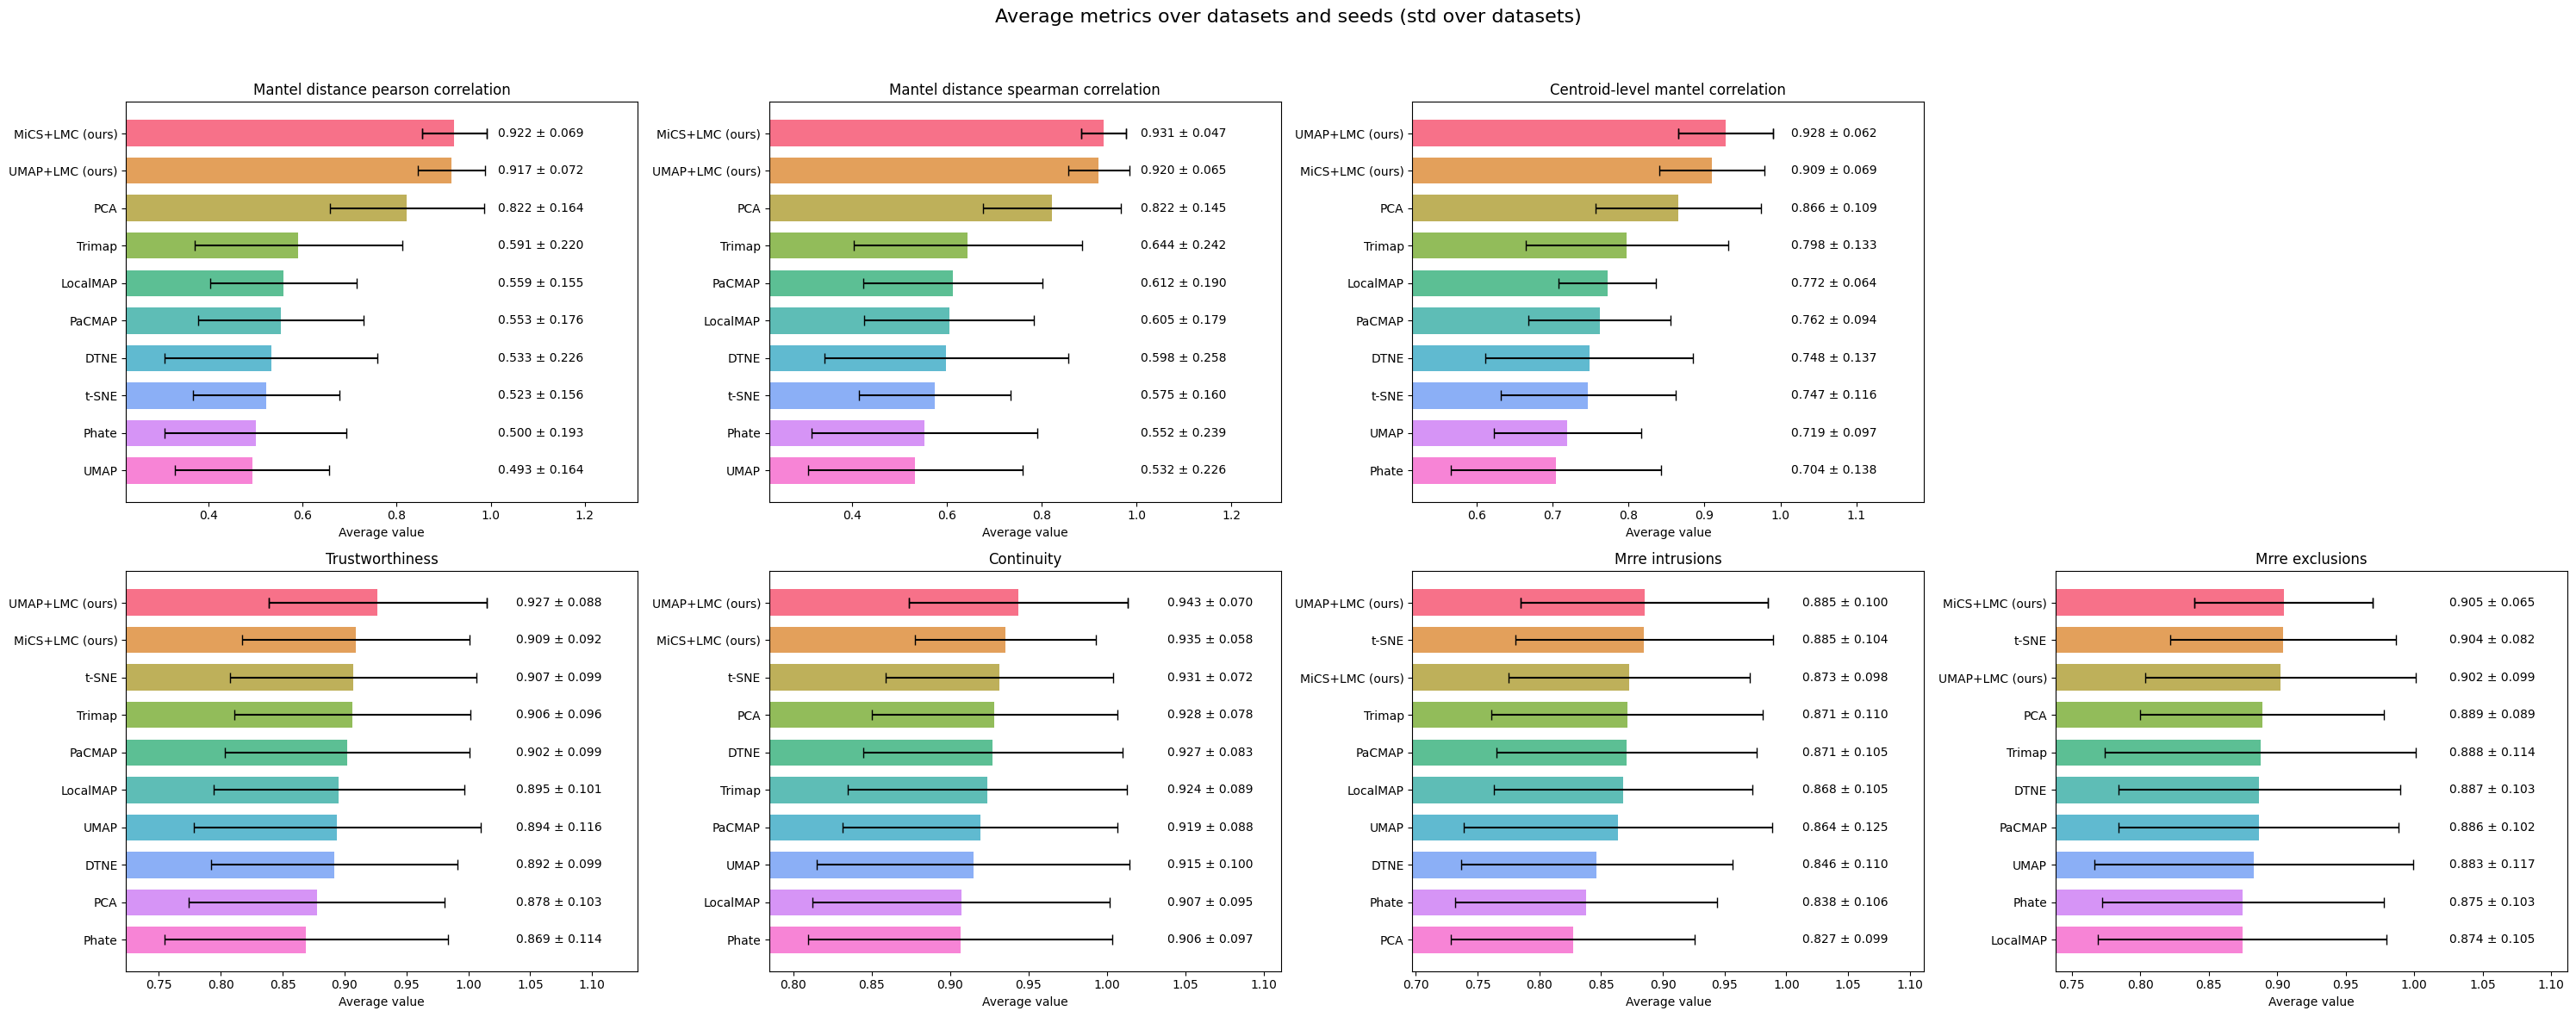

In [5]:
import os
from typing import Dict, Tuple, Iterable, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Average values from your long df (dataset, method, seed, metrics...)
# =========================
def average_values_from_seed_long_df(
    df_long: pd.DataFrame,
    lower_is_better: Iterable[str] = ("MRRE Intrusions", "MRRE Exclusions"),
) -> Dict[str, pd.DataFrame]:
    """
    Accepts your long df with columns:
      dataset, method, seed, <metric columns...>
    Returns a dict: {metric_display_name: summary_df}, where summary_df columns are
      ['method', 'avg_value', 'std_value', 'n_datasets'] sorted by avg_value desc.
    """
    required = {"dataset", "method", "seed"}
    if not required.issubset(df_long.columns):
        missing = required - set(df_long.columns)
        raise ValueError(f"Missing columns: {missing}")

    # Identify metric columns by excluding the key columns
    key_cols = ["dataset", "method", "seed"]
    metric_cols = [c for c in df_long.columns if c not in key_cols]

    # First aggregate over seeds to get one value per (dataset, method) for each metric
    agg = df_long.groupby(["dataset", "method"], as_index=False)[metric_cols].mean()

    out = {}
    for metric in metric_cols:
        # lower_is_better -> sort ascending; else descending
        asc = metric in lower_is_better

        # summarize across datasets
        summary = (agg.groupby("method")[metric]
                   .agg(avg_value="mean", std_value="std", n_datasets="count")
                   .reset_index()
                   .sort_values("avg_value", ascending=not asc))
        out[metric] = summary

    return out

# =========================
# 2) Plotting: average value ± std (2x4 subplot)
# =========================
def plot_average_value_bars(
    values_by_metric: Dict[str, pd.DataFrame],
    outdir: str = "fig-avg-values",
    formats: Tuple[str, ...] = ("png", "pdf"),
    dpi: int = 400,
    title_prefix: str = "Average metrics over datasets and seeds (std over datasets)",
    figsize: Tuple[float, float] = (30, 12),  # Increased width from 24 to 30
    x_limit_pad: float = 0.12,  # Increased from 0.08 for even wider plots
):
    """
    values_by_metric: output of average_values_from_seed_long_df
    Creates a 2x4 subplot of horizontal bar charts.
    """
    os.makedirs(outdir, exist_ok=True)

    # Set the style without grid
    plt.style.use('default')
    palette = sns.color_palette("husl", n_colors=10)

    # Create figure with 2x4 subplots
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()

    for idx, (metric_name, df) in enumerate(values_by_metric.items()):
        if idx >= 7:  # Only show first 7 metrics
            break
            
        # Adjust index to flip rows - first 4 plots go in second row, last 3 in first row
        plot_idx = (idx + 4) % 8
        ax = axes[plot_idx]
        
        plot_df = df.copy().sort_values("avg_value", ascending=False)
        methods = plot_df["method"].tolist()
        y = np.arange(len(methods))
        
        # Create bar plot with larger bars
        bars = ax.barh(y=y,
                      width=plot_df["avg_value"],
                      xerr=plot_df["std_value"],
                      color=palette,
                      alpha=0.8,
                      capsize=4,
                      height=0.7)

        # Highlight best performer
        best_color = sns.color_palette("husl", n_colors=1)[0]
        ax.barh(y=[y[0]],
                width=[plot_df["avg_value"].iloc[0]],
                xerr=[plot_df["std_value"].iloc[0]],
                color=best_color,
                alpha=1.0,
                capsize=4,
                height=0.7)

        # Add value ± std text with larger font
        max_width = max(plot_df["avg_value"] + plot_df["std_value"])
        text_start = max_width + x_limit_pad * 0.2
        for i, (avg, std) in enumerate(zip(plot_df["avg_value"], plot_df["std_value"])):
            ax.text(text_start, i,
                   f'{avg:.3f} ± {std:.3f}',
                   va='center',
                   fontsize=10)

        ax.set_yticks(y)
        ax.set_yticklabels(methods, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("Average value", fontsize=10)
        ax.set_title(f"{metric_name.capitalize()}", fontsize=12)

        # Set x-limits with more padding
        min_v = (plot_df["avg_value"] - plot_df["std_value"]).min()
        max_v = max_width
        pad = (max_v - min_v) * x_limit_pad
        text_space = (max_v - min_v) * 0.35  # Increased from 0.25 for wider text area
        ax.set_xlim(min_v - pad, max_v + pad + text_space)

    # Hide the last subplot in the first row (index 3)
    axes[3].set_visible(False)

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust rect to prevent empty space at top

    base = os.path.join(outdir, "avg_values_subplot")
    #plt.show()
    for fmt in formats:
        print(f"{base}.{fmt}")
        fig.savefig(f"{base}.{fmt}", dpi=dpi if fmt.lower()=="png" else None,
                    bbox_inches="tight")
    
    plt.show()
    plt.close(fig)


# =========================
# 4) Example usage
# =========================

df = csv

values_by_metric = average_values_from_seed_long_df(
    df,
    lower_is_better=[]  # adjust if needed
)

# Plot as 2x4 subplot
plot_average_value_bars(values_by_metric, outdir="fig-avg-values")


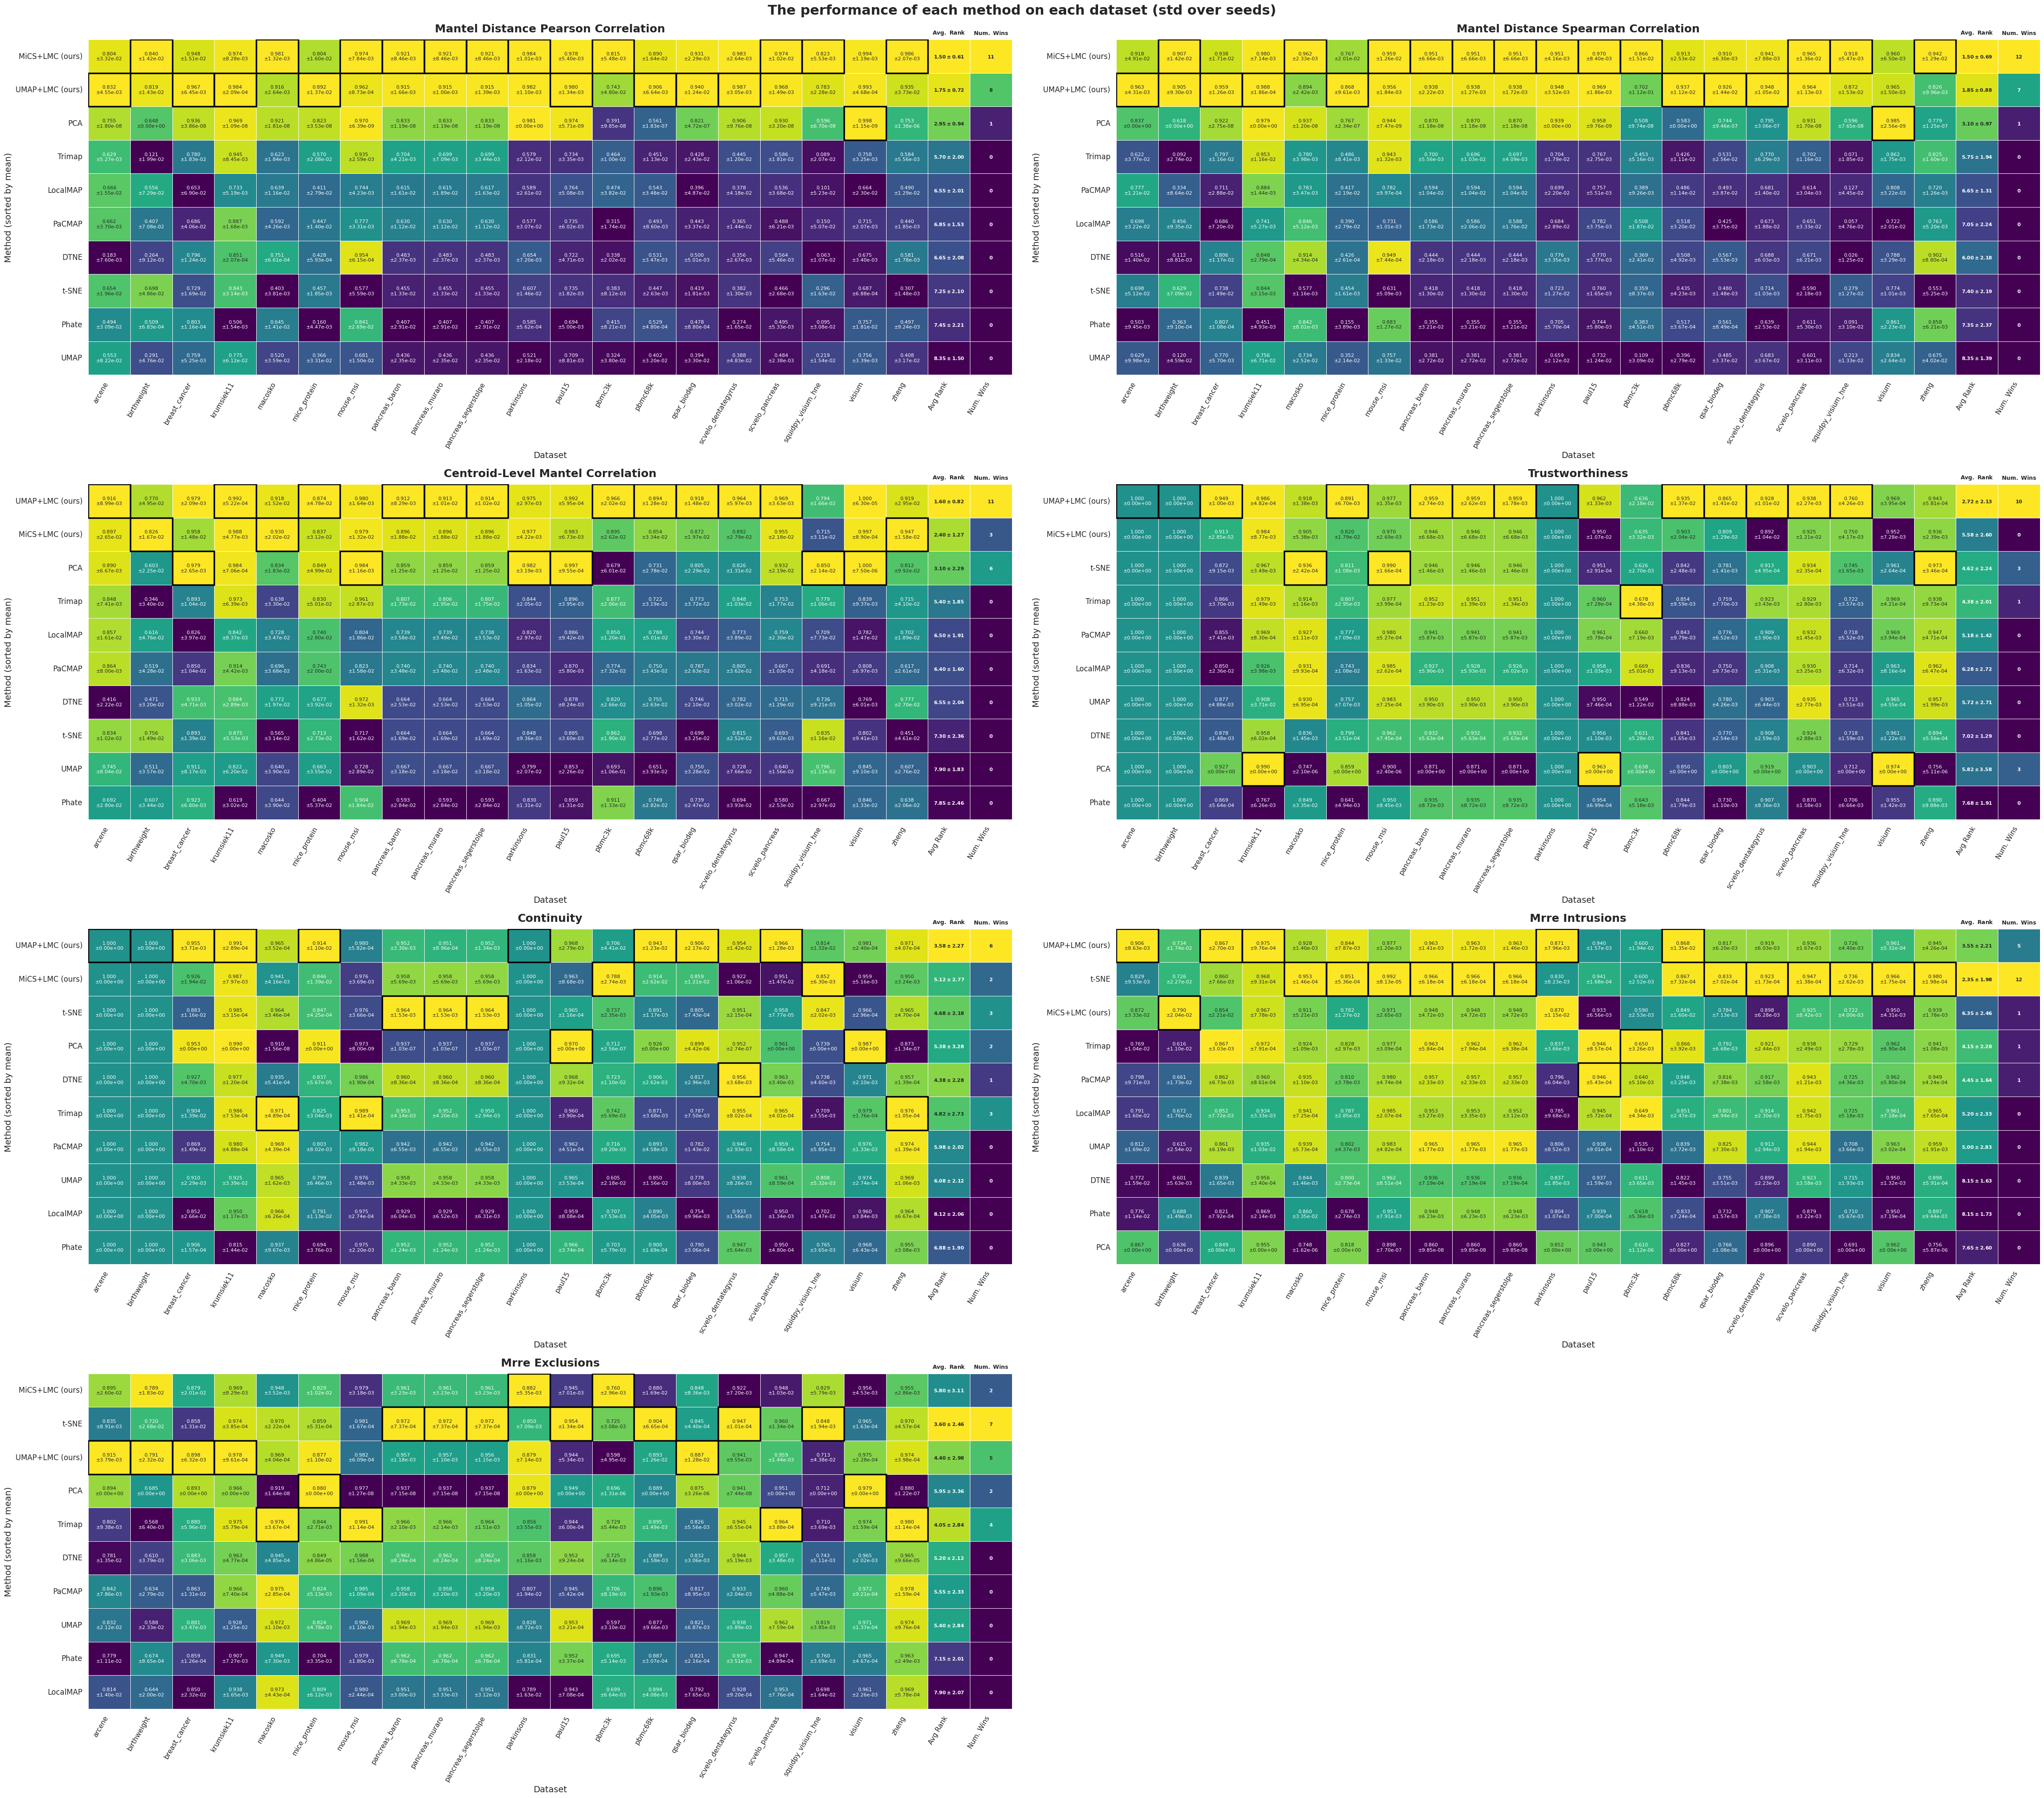

In [22]:
# START_CODE_TAG
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- Inputs ---
# DataFrame `csv` with columns: seed, dataset, method, metric_1 ... metric_N
assert {'seed','dataset','method'}.issubset(csv.columns), "csv must have seed,dataset,method."
metrics = list(csv.columns[3:])

# Mark which metrics are higher-is-better (flip to False for error metrics, etc.)
higher_is_better = [True]*len(metrics)  # e.g. [True,True,True,True, True,True,False]

# Orders (tweak if you want a custom order)
datasets_order = sorted(csv['dataset'].unique().tolist())
# We'll sort methods per metric by their *mean across datasets* below.

# --- Aggregate across seeds ---
agg = csv.groupby(['dataset','method'])[metrics].agg(['mean','std']).sort_index()

# --- Styling ---
sns.set_theme(style="white", font_scale=1.3)
n_metrics = len(metrics)
n_rows = (n_metrics + 1) // 2  # Round up division
fig, axes = plt.subplots(n_rows, 2, figsize=(46, 10*n_rows), constrained_layout=True)  # Increased width for extra columns
axes = axes.flatten()

# We'll use a per-dataset (column-wise) min–max normalization for the colormap.
# The heatmap values will therefore be in [0,1] everywhere
cmap = sns.color_palette("viridis", as_cmap=True)
vmin, vmax = 0.0, 1.0
annot_kws = {"fontsize": 8}

def col_minmax_normalize(df):
    """Column-wise (per dataset) min–max normalization to [0,1], robust to equal columns."""
    norm = df.copy().astype(float)
    for c in norm.columns:
        col = norm[c].values.astype(float)
        mn = np.nanmin(col)
        mx = np.nanmax(col)
        if not np.isfinite(mn) or not np.isfinite(mx):
            norm[c] = np.nan
        elif np.isclose(mx, mn):  # constant column
            norm[c] = 0.5  # or 0, but 0.5 emphasizes 'all equal'
        else:
            norm[c] = (col - mn) / (mx - mn)
    return norm

# Reorder metrics to show correlation metrics first
correlation_metrics = [m for m in metrics if 'correlation' in m.lower()]
other_metrics = [m for m in metrics if 'correlation' not in m.lower()]
metrics = correlation_metrics + other_metrics

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Make (methods × datasets) matrices
    mean_df_raw = agg[(metric, 'mean')].unstack('dataset').reindex(columns=datasets_order)
    std_df      = agg[(metric, 'std')].unstack('dataset').reindex(columns=datasets_order)

    # Calculate average rank across datasets
    maximize = higher_is_better[i]
    ranks = mean_df_raw.rank(ascending=not maximize)
    avg_ranks = ranks.mean(axis=1)
    avg_ranks_std = ranks.std(axis=1)
    
    # Calculate number of wins per method
    wins = (ranks == 1).sum(axis=1)
    
    # Sort methods by their mean across datasets (descending if higher-is-better)
    method_means = mean_df_raw.mean(axis=1, skipna=True)
    methods_sorted = method_means.sort_values(ascending=not maximize).index
    mean_df_raw = mean_df_raw.reindex(index=methods_sorted)
    std_df = std_df.reindex(index=methods_sorted)
    avg_ranks = avg_ranks.reindex(index=methods_sorted)
    avg_ranks_std = avg_ranks_std.reindex(index=methods_sorted)
    wins = wins.reindex(index=methods_sorted)

    # Add rank and wins columns
    mean_df_raw['Avg Rank'] = avg_ranks.round(2)
    mean_df_raw['Num. Wins'] = wins
    std_df['Avg Rank'] = avg_ranks_std
    std_df['Num. Wins'] = np.nan  # No std for wins

    # Annotations (original numbers): "mean\n±std"
    annot = mean_df_raw.copy().astype(object)
    for r in mean_df_raw.index:
        for c in mean_df_raw.columns:
            if c == 'Avg Rank':
                m = mean_df_raw.loc[r, c]
                s = std_df.loc[r, c]
                annot.loc[r, c] = f"$\\mathbf{{{m:.2f} \\pm {s:.2f}}}$"
            elif c == 'Num. Wins':
                annot.loc[r, c] = f"$\\mathbf{{{int(mean_df_raw.loc[r, c])}}}$"
            else:
                m = mean_df_raw.loc[r, c]
                s = std_df.loc[r, c]
                if pd.isna(m):
                    annot.loc[r, c] = ""
                else:
                    annot.loc[r, c] = f"{m:.3f}\n±{(0.0 if pd.isna(s) else s):.2e}"

    # Normalized (per column) version for coloring only
    mean_df_norm = col_minmax_normalize(mean_df_raw.drop(['Avg Rank', 'Num. Wins'], axis=1))
    # For Avg Rank, invert the normalization so lower ranks get higher values
    rank_norm = col_minmax_normalize(pd.DataFrame(avg_ranks))
    mean_df_norm['Avg Rank'] = 1 - rank_norm
    # For Num. Wins, normalize directly
    wins_norm = col_minmax_normalize(pd.DataFrame(wins))
    mean_df_norm['Num. Wins'] = wins_norm

    # Heatmap
    sns.heatmap(
        mean_df_norm,
        ax=ax,
        cmap=cmap,
        vmin=vmin, vmax=vmax,  # shared scale [0,1]
        annot=annot,
        fmt="",
        annot_kws=annot_kws,
        linewidths=0.5,
        linecolor="white",
        cbar=False,
        square=False
    )

    # Outline the best method per dataset (column) using RAW means
    for cidx, col in enumerate(mean_df_raw.columns):
        if col in ['Avg Rank', 'Num. Wins']:
            continue
        col_vals = mean_df_raw[col].values.astype(float)  # across methods (rows)
        if np.all(np.isnan(col_vals)):
            continue
        best_ridx = (np.nanargmax(col_vals) if maximize else np.nanargmin(col_vals))
        ax.add_patch(Rectangle((cidx, best_ridx), 1, 1, fill=False, edgecolor="black", linewidth=2.5))

    # Titles & labels
    ax.set_title(metric.replace("_", " ").title(), fontsize=18, weight="bold", pad=12)
    ax.set_xlabel("Dataset", fontsize=14)
    ax.set_ylabel("Method (sorted by mean)", fontsize=14)

    # Add column headers above the rank and wins columns
    ax.text(len(datasets_order) + 0.5, -0.2, "$\\mathbf{Avg.~Rank}$", ha='center', va='center', fontsize=9)
    ax.text(len(datasets_order) + 1.5, -0.2, "$\\mathbf{Num.~Wins}$", ha='center', va='center', fontsize=9)

    # Tick label sizes & rotation (20 datasets on x)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right", fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

# Hide any unused subplots
for i in range(len(metrics), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "The performance of each method on each dataset (std over seeds)",
    fontsize=22, weight="bold", y=1.01
)

# Optional high-res exports
# plt.savefig("metric_tables_heatmap_per_col_norm.pdf", bbox_inches="tight")
plt.savefig("metric_tables_heatmap_per_col_norm.png", dpi=400, bbox_inches="tight")

plt.show()
# END_CODE_TAG
